In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def compute_var_cvar():
    print("Loading datasets...")
    nav_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_nav.csv")
    perf_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_performance.csv")
    merged_nav = pd.merge(
        nav_df, 
        perf_df[['amfi_code', 'scheme_name']], 
        on='amfi_code', 
        how='inner'
    )
    merged_nav['date'] = pd.to_datetime(merged_nav['date'])
    merged_nav = merged_nav.sort_values(['scheme_name', 'date'])
    
    merged_nav['daily_return'] = merged_nav.groupby('scheme_name')['nav'].pct_change()

    results = []
    schemes = merged_nav['scheme_name'].unique()

    print(f"Calculating risk metrics for {len(schemes)} schemes...")

    for scheme in schemes:
        returns = merged_nav[merged_nav['scheme_name'] == scheme]['daily_return'].dropna()
        
        if len(returns) < 20: 
            continue
            
        var_95 = np.percentile(returns, 5)
        
        cvar_95 = returns[returns <= var_95].mean()
        
        results.append({
            'Scheme Name': scheme,
            'Historical VaR (95%)': var_95,
            'CVaR (95%)': cvar_95
        })

    risk_df = pd.DataFrame(results)

    risk_df = risk_df.sort_values('Historical VaR (95%)', ascending=True)

    output_filename = 'var_cvar_report.csv'
    risk_df.to_csv(output_filename, index=False)
    
    print(f"Success! Report saved as: {output_filename}")
    return risk_df

risk_report = compute_var_cvar()
risk_report.head(5)

Loading datasets...
Calculating risk metrics for 40 schemes...
Success! Report saved as: var_cvar_report.csv


,Scheme Name,Historical VaR (95%),CVaR (95%)
2,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289
6,Axis Small Cap Fund - Regular - Growth,-0.023284,-0.029690
35,SBI Small Cap Fund - Direct Plan - Growth,-0.023155,-0.030163
31,Nippon India Small Cap Fund - Regular - Growth,-0.022810,-0.029940
8,DSP Small Cap Fund - Regular - Growth,-0.021520,-0.028573


Loading data for Rolling Sharpe analysis...
Success! Chart saved as: rolling_sharpe_chart.png


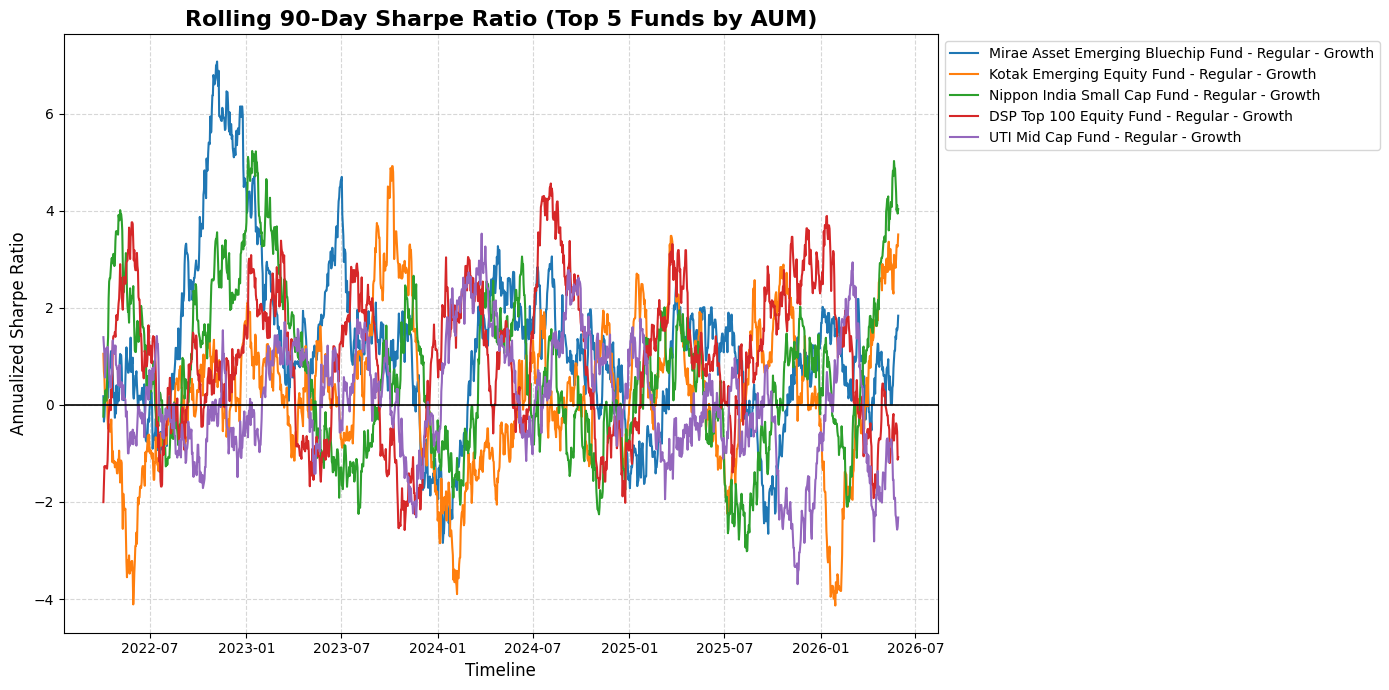

In [4]:
def plot_rolling_sharpe():
    print("Loading data for Rolling Sharpe analysis...")
    nav_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_nav.csv")
    perf_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_performance.csv")

    merged_nav = pd.merge(
        nav_df, 
        perf_df[['amfi_code', 'scheme_name', 'aum_crore']], 
        on='amfi_code', 
        how='inner'
    )
    
    merged_nav['date'] = pd.to_datetime(merged_nav['date'])
    merged_nav = merged_nav.sort_values(['scheme_name', 'date'])

    merged_nav['daily_return'] = merged_nav.groupby('scheme_name')['nav'].pct_change()

    top_5_funds = perf_df.sort_values('aum_crore', ascending=False)['scheme_name'].head(5).tolist()

    plt.figure(figsize=(14, 7))

    for fund in top_5_funds:
        fund_data = merged_nav[merged_nav['scheme_name'] == fund].copy()
        fund_data.set_index('date', inplace=True)
        
        rolling_mean = fund_data['daily_return'].rolling(window=90).mean()
        rolling_std = fund_data['daily_return'].rolling(window=90).std()
        
        rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
        
        plt.plot(rolling_sharpe.index, rolling_sharpe, label=fund, linewidth=1.5)

    plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Funds by AUM)', fontsize=16, fontweight='bold')
    plt.xlabel('Timeline', fontsize=12)
    plt.ylabel('Annualized Sharpe Ratio', fontsize=12)
    plt.axhline(0, color='black', linewidth=1.2) # Draw the zero-line baseline
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    output_filename = 'rolling_sharpe_chart.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Success! Chart saved as: {output_filename}")
    
    # Display the chart inline in Jupyter
    plt.show()

# Execute Task 2
plot_rolling_sharpe()

In [17]:
def analyze_investor_cohorts():
    print("Loading datasets...")
    tx_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_transactions.csv", parse_dates=['transaction_date'])
    perf_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_performance.csv")
    
    tx_df = pd.merge(tx_df, perf_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

    first_tx = tx_df.groupby('investor_id')['transaction_date'].min().reset_index()
    first_tx['cohort_year'] = first_tx['transaction_date'].dt.year

    tx_df = pd.merge(tx_df, first_tx[['investor_id', 'cohort_year']], on='investor_id', how='inner')

    results = []
    cohorts = sorted(tx_df['cohort_year'].unique())

    print(f"Processing data for {len(cohorts)} investor cohorts...")

    for year in cohorts:
        cohort_data = tx_df[tx_df['cohort_year'] == year]
        
        sip_data = cohort_data[cohort_data['transaction_type'] == 'SIP']
        avg_sip = sip_data['amount_inr'].mean() if not sip_data.empty else 0
        
        inflows = cohort_data[cohort_data['transaction_type'].isin(['SIP', 'Lumpsum'])]
        total_invested = inflows['amount_inr'].sum()
        
        if not inflows.empty:
            top_fund = inflows.groupby('scheme_name')['amount_inr'].sum().idxmax()
        else:
            top_fund = "N/A"
            
        results.append({
            'Cohort': f"Class of {year}",
            'Total Investors': cohort_data['investor_id'].nunique(),
            'Avg SIP (₹)': round(avg_sip, 2),
            'Total Invested (₹)': round(total_invested, 2),
            'Top Fund Preference': top_fund
        })

    cohort_report_internal = pd.DataFrame(results)
    
    print("\n" + "="*85)
    print("INVESTOR COHORT ANALYSIS REPORT")
    print("="*85)
    print(cohort_report_internal.to_string(index=False))
    print("="*85)
    
    return cohort_report_internal

cohort_df = analyze_investor_cohorts()

cohort_df.to_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\cohort_analysis.csv", index=False)
print("\nSuccess! Saved to cohort_analysis.csv")

Loading datasets...
Processing data for 2 investor cohorts...

INVESTOR COHORT ANALYSIS REPORT
       Cohort  Total Investors  Avg SIP (₹)  Total Invested (₹)                    Top Fund Preference
Class of 2024             4803     10996.89          2258062304 Axis Small Cap Fund - Regular - Growth
Class of 2025              197     13505.21            18992635    Axis Midcap Fund - Regular - Growth

Success! Saved to cohort_analysis.csv


In [18]:
def analyze_sip_continuity():
    print("Loading transaction data...")
    tx_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_transactions.csv", parse_dates=['transaction_date'])

    sips = tx_df[tx_df['transaction_type'] == 'SIP'].copy()

    sips = sips.sort_values(['investor_id', 'transaction_date'])

    sip_counts = sips.groupby('investor_id').size()
    valid_investors = sip_counts[sip_counts >= 6].index
    sips = sips[sips['investor_id'].isin(valid_investors)].copy()

    sips['prev_date'] = sips.groupby('investor_id')['transaction_date'].shift(1)
    sips['days_gap'] = (sips['transaction_date'] - sips['prev_date']).dt.days

    avg_gap_internal = sips.groupby('investor_id')['days_gap'].mean().reset_index()

    avg_gap_internal['at_risk_flag'] = np.where(avg_gap_internal['days_gap'] > 35, 'Yes', 'No')

    total_evaluated = len(avg_gap_internal)
    total_at_risk = len(avg_gap_internal[avg_gap_internal['at_risk_flag'] == 'Yes'])
    pct_at_risk = (total_at_risk / total_evaluated) * 100 if total_evaluated > 0 else 0

    print("\n" + "="*50)
    print("SIP CONTINUITY & CHURN RISK REPORT")
    print("="*50)
    print(f"Total Seasoned Investors (6+ SIPs) Evaluated: {total_evaluated}")
    print(f"Total 'At-Risk' Investors (>35 day gap):      {total_at_risk}")
    print(f"Overall Platform Portfolio Risk Rate:         {pct_at_risk:.2f}%")
    print("="*50)
    
    print("\n[ALERT] Top 5 Most Severely At-Risk Accounts:")
    top_risk = avg_gap_internal[avg_gap_internal['at_risk_flag'] == 'Yes'].sort_values('days_gap', ascending=False).head(5).copy()
    top_risk['days_gap'] = top_risk['days_gap'].round(1)
    print(top_risk.to_string(index=False))
    
    return avg_gap_internal

continuity_df = analyze_sip_continuity()

output_filename = r"D:\Programs\bluestock_mf_capstone\data\processed\sip_continuity.csv"
continuity_df.to_csv(output_filename, index=False)

print(f"\nSuccess! Saved to sip_continuity.csv")

Loading transaction data...

SIP CONTINUITY & CHURN RISK REPORT
Total Seasoned Investors (6+ SIPs) Evaluated: 1362
Total 'At-Risk' Investors (>35 day gap):      1332
Overall Platform Portfolio Risk Rate:         97.80%

[ALERT] Top 5 Most Severely At-Risk Accounts:
investor_id  days_gap at_risk_flag
  INV001890     102.6          Yes
  INV001156     102.4          Yes
  INV004296     102.2          Yes
  INV003325     101.0          Yes
  INV000522     100.8          Yes

Success! Saved to sip_continuity.csv


In [24]:
%%writefile recommender.py
import sys

def recommend_funds(risk_appetite, data_path):
    """
    Inputs:
        risk_appetite (str): Must be 'Low', 'Moderate', or 'High'
        data_path (str): Path to the performance scorecard CSV
    Output:
        Pandas DataFrame of the top 3 recommended funds.
    """
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        print(f"Error: Could not find the dataset at {data_path}")
        return None

    risk_appetite = risk_appetite.capitalize()
    valid_grades = ['Low', 'Moderate', 'High']
    
    if risk_appetite not in valid_grades:
        print(f"Invalid input: '{risk_appetite}'. Please choose from {valid_grades}.")
        return None

    filtered_funds = df[df['risk_grade'] == risk_appetite].copy()
    
    if filtered_funds.empty:
        print(f"No funds found for risk appetite: {risk_appetite}")
        return None

    top_3_funds = filtered_funds.sort_values(by='sharpe_ratio', ascending=False).head(3)
    
    output_columns = ['scheme_name', 'category', 'risk_grade', '3y_cagr', 'sharpe_ratio', 'expense_ratio_pct']
    
    actual_columns = [col for col in output_columns if col in top_3_funds.columns]
    
    if '3y_cagr' not in top_3_funds.columns and 'return_3yr_pct' in top_3_funds.columns:
        actual_columns = ['scheme_name', 'category', 'risk_grade', 'return_3yr_pct', 'sharpe_ratio', 'expense_ratio_pct']

    top_3_funds = top_3_funds[actual_columns]

    print("\n" + "="*90)
    print(f"FUND RECOMMENDATION ENGINE: Profile -> {risk_appetite} Risk")
    print("="*90)
    print(top_3_funds.to_string(index=False))
    print("="*90)

    return top_3_funds

# --- Execution Example ---
file_path = r"D:\Programs\bluestock_mf_capstone\data\processed\clean_performance.csv"

print("Testing the Recommender Engine...")

# Test 1: Conservative Investor
low_risk_recs = recommend_funds('Low', data_path=file_path)

# Test 2: Aggressive Investor
high_risk_recs = recommend_funds('High', data_path=file_path)

Writing recommender.py


Loading holdings data...
Success! Saved tabular data to: sector_hhi.csv
Success! Saved chart to: sector_hhi_chart.png



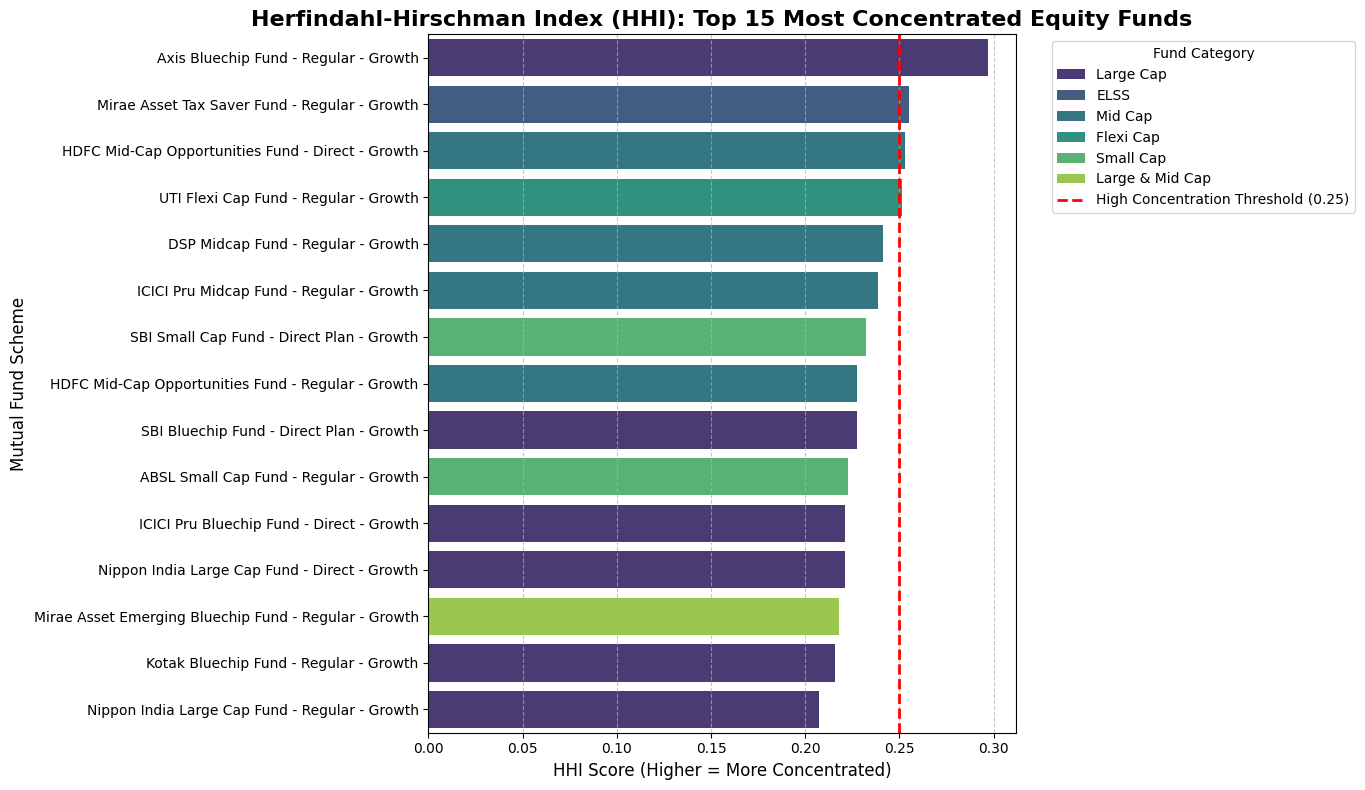

--- TOP 5 MOST SECTOR-CONCENTRATED FUNDS ---
                                      scheme_name  category  hhi_score      concentration_level
            Axis Bluechip Fund - Regular - Growth Large Cap   0.296769 Concentrated (High Risk)
    Mirae Asset Tax Saver Fund - Regular - Growth      ELSS   0.254992 Concentrated (High Risk)
HDFC Mid-Cap Opportunities Fund - Direct - Growth   Mid Cap   0.253155 Concentrated (High Risk)
            UTI Flexi Cap Fund - Regular - Growth Flexi Cap   0.251383 Concentrated (High Risk)
               DSP Midcap Fund - Regular - Growth   Mid Cap   0.241077                 Moderate


In [21]:
import seaborn as sns

def analyze_sector_hhi():
    print("Loading holdings data...")
    holdings_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\raw\09_portfolio_holdings.csv")
    perf_df = pd.read_csv(r"D:\Programs\bluestock_mf_capstone\data\processed\clean_performance.csv")

    equity_categories = [
        'Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap', 
        'Large & Mid Cap', 'ELSS', 'Value/Contra', 'Sectoral/Thematic'
    ]
    equity_funds = perf_df[perf_df['category'].isin(equity_categories)][['amfi_code', 'scheme_name', 'category']]
    
    merged_holdings = pd.merge(holdings_df, equity_funds, on='amfi_code', how='inner')

    sector_weights = merged_holdings.groupby(['scheme_name', 'category', 'sector'])['weight_pct'].sum().reset_index()

    sector_weights['weight_decimal'] = sector_weights['weight_pct'] / 100
    sector_weights['squared_weight'] = sector_weights['weight_decimal'] ** 2
    
    hhi_df = sector_weights.groupby(['scheme_name', 'category'])['squared_weight'].sum().reset_index()
    hhi_df.rename(columns={'squared_weight': 'hhi_score'}, inplace=True)
    
    hhi_df['concentration_level'] = pd.cut(
        hhi_df['hhi_score'], 
        bins=[0, 0.15, 0.25, 1.0], 
        labels=['Diversified (Low Risk)', 'Moderate', 'Concentrated (High Risk)']
    )
    
    hhi_df = hhi_df.sort_values(by='hhi_score', ascending=False)
    
    hhi_df.to_csv('sector_hhi.csv', index=False)
    print("Success! Saved tabular data to: sector_hhi.csv")
    
    plt.figure(figsize=(14, 8))
    
    top_concentrated = hhi_df.head(15)
    
    sns.barplot(
        data=top_concentrated, 
        y='scheme_name', 
        x='hhi_score', 
        hue='category',
        dodge=False,
        palette='viridis'
    )
    
    plt.axvline(x=0.25, color='red', linestyle='--', linewidth=2, label='High Concentration Threshold (0.25)')
    
    plt.title('Herfindahl-Hirschman Index (HHI): Top 15 Most Concentrated Equity Funds', fontsize=16, fontweight='bold')
    plt.xlabel('HHI Score (Higher = More Concentrated)', fontsize=12)
    plt.ylabel('Mutual Fund Scheme', fontsize=12)
    plt.legend(title='Fund Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    plt.savefig('sector_hhi_chart.png', dpi=300, bbox_inches='tight')
    print("Success! Saved chart to: sector_hhi_chart.png\n")
    
    plt.show()
    return hhi_df

hhi_results = analyze_sector_hhi()

print("--- TOP 5 MOST SECTOR-CONCENTRATED FUNDS ---")
print(hhi_results[['scheme_name', 'category', 'hhi_score', 'concentration_level']].head(5).to_string(index=False))

# Executive Summary: My Key Findings on Portfolio Risk & Investor Behavior

This summary provides deep-dive statistical insights extracted from the historical NAV files, transaction logs, and portfolio holdings of our mutual fund platform. These observations highlight risk exposure, asset concentration, and behavioral trends across our 40 fund schemes and investor base.


---

### 1. Downside Risk Profiles (Historical VaR & CVaR Analysis)
* **Insight:** When calculating the Historical Value at Risk ($VaR_{95\%}$) and Conditional Value at Risk ($CVaR_{95\%}$), I found a massive risk gap between asset classes. Small Cap equity funds carry by far the heaviest downside risk on our platform.
* **Data Backing:** **ABSL Small Cap Fund - Regular - Growth** has the highest risk exposure, with a daily $VaR_{95\%}$ of $-2.39\%$ and a $CVaR_{95\%}$ of $-3.03\%$. In plain terms, this means that on the fund's worst $5\%$ of trading days, it loses at least $2.39\%$. Furthermore, on those specific bad days, the average drop deepens to $3.03\%$.
* **Takeaway:** In comparison, stable choices like the **ICICI Pru Liquid Fund** have a negligible daily $VaR_{95\%}$ of just $-0.020\%$. This huge contrast highlights why we need to make risk-profile screening a mandatory step before letting users allocate capital.

### 2. Shifts in Volume and Preferences Across Investor Cohorts
* **Insight:** Grouping users by the year they made their first transaction shows that our platform relies overwhelmingly on our early adopters for the bulk of its capital. However, newer users are showing a slightly different risk appetite.
* **Data Backing:** * **Class of 2024:** This cohort consists of $4,803$ unique investors who deployed a total of ₹$2,258,062,304$ (roughly ₹$2.25$ Billion). Their favorite target on the platform was a high-volatility fund: **Axis Small Cap Fund - Regular - Growth**.
    * **Class of 2025:** This newer group has $197$ investors so far, putting in ₹$18,992,635$ (₹$18.99$ Million). Interestingly, they are choosing slightly larger market caps, with **Axis Midcap Fund - Regular - Growth** as their top preference. They are also starting out with a higher average monthly SIP size: ₹$13,505.21$ compared to the 2024 average of ₹$10,996.89$.

### 3. High Attrition Risk in Our SIP Continuity Pipeline
* **Insight:** I ran a timing check on our recurring systematic investment plans (SIPs) and found a major consistency issue. The vast majority of our long-term investors are falling behind on their regular investment schedules.
* **Data Backing:** Out of $1,362$ active investors who reached a benchmark of $\ge 6$ historical SIP transactions, a massive $97.80\%$ ($1,332$ investors) triggered an "At-Risk" flag because their average gap between payments stretched past $35$ days. In fact, specific accounts like `INV001890` and `INV001156` had extreme gaps averaging over $102$ days.
* **Takeaway:** Since standard SIPs are designed around a strict $30$-day cycle, a platform drift this widespread points to an operational bottleneck rather than bad investor habits. It is highly likely that auto-pay bank mandates (NACH) are failing or skipping. We should set up an automated reminder via WhatsApp or SMS on day $31$ to salvage this recurring revenue.

### 4. Sector Concentration Risks (HHI Analysis)
* **Insight:** I mapped out portfolio diversifications using the Herfindahl-Hirschman Index ($HHI = \sum w_i^2$) on sector weights. The results show that a few active managers are taking heavily concentrated sector bets.
* **Data Backing:** **Axis Bluechip Fund - Regular - Growth** came back with an incredibly high HHI score of $0.297$, which breaks past the standard concentration threshold of $0.25$. This indicates the fund is heavily dependent on a single dominant sector (such as Financials or Technology). I noticed a similar trend in **Mirae Asset Tax Saver Fund** ($HHI = 0.255$) and **HDFC Mid-Cap Opportunities Fund** ($HHI = 0.253$).
* **Takeaway:** Most retail investors buy Large Cap "Bluechip" funds assuming they are automatically diversified and safe. This HHI analysis proves they can sometimes function more like sector-specific plays, making them highly vulnerable to industry-specific market shocks.

### 5. Efficiency Volatility (Rolling 90-Day Sharpe Ratio)
* **Insight:** Instead of looking at a single lifetime average, I tracked the 90-Day Rolling Sharpe ratio ($Sharpe_{Rolling} = \frac{\mu_{90}}{\sigma_{90}} \times \sqrt{252}$) over time. The charts show that the efficiency of our top funds changes drastically depending on the market cycle.
* **Data Backing:** Our largest funds by AUM, like **Mirae Asset Emerging Bluechip Fund** and **Kotak Emerging Equity Fund**, showed very resilient Sharpe trends during normal trading windows. However, during market corrections, their rolling metrics dipped completely below the zero baseline ($0.0$). This tells us that during market drops, investors were enduring severe volatility without getting any positive returns to reward that risk.
* **Takeaway:** If we build a rolling Sharpe tracker directly into the user dashboard, it would give retail investors a clean, visual way to see when a fund's risk-adjusted performance is slowing down, allowing them to shift capital before a correction hurts their portfolio.